<a href="https://colab.research.google.com/github/alviglio/AlbJupyters/blob/main/SivaGuenterPeterBook/Chapter01draft01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1: Water Balance Across Climates - Exploring Catchments with R

![Lake Titicaca on the Andes from Bolivia](https://upload.wikimedia.org/wikipedia/commons/d/d3/Lake_Titicaca_on_the_Andes_from_Bolivia.jpg?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=original)

## Introduction

Water is constantly moving through landscapes. Some of the precipitation that falls on a catchment returns to the atmosphere through evaporation and transpiration, while some leaves the catchment as streamflow. The balance between these fluxes is one of the central questions in hydrology.

This notebook introduces basic catchment water-balance analysis using R. We will work with daily hydrologic data from selected MOPEX catchments in the United States and use them to calculate annual precipitation, potential evaporation, and runoff.

The exercises begin with simple data handling: downloading daily files, reading fixed-width text data, and organizing station information. We then use the data to reproduce a series of figures showing how precipitation and discharge vary through time and across regions.

The main questions we explore are:

- How different are annual runoff patterns between humid and dry catchments?
- How much of annual precipitation becomes streamflow?
- How much water is lost to evaporation and transpiration?
- How do catchments compare in a Budyko-style water-balance framework?

By the end of the notebook, we will move from raw daily data to summary water-balance diagrams that help explain how climate controls the partitioning of water into runoff and evapotranspiration.

## Download selected MOPEX daily streamflow files

In this step, we download a small subset of MOPEX daily data files that will be used in the exercises.  
Rather than downloading the full MOPEX archive, we only retrieve the station files needed for the examples in this notebook.

Each MOPEX station is identified by a USGS station ID, such as `02387500` for the Oostanaula River at Resaca, Georgia.  
The daily data files use the station ID as the filename and have the extension `.dly`.

The code below does four things:

1. Creates a local folder called `data`, if it does not already exist.
2. Defines the list of station IDs used in the exercises.
3. Builds a web address for each `.dly` file.
4. Downloads each file into the local `data` folder.

After the files are downloaded, `list.files("data")` shows the contents of the folder so that we can check that the download worked.

In [9]:
dir.create("data", showWarnings = FALSE)

station_ids <- c("02387500", "07144200", "09497500", "01606500",
                 "14359000", "05482500", "01064500", "08095000",
                "01334500", "03167000", "02296750", "12098500")

base_url <- "https://raw.githubusercontent.com/feng-ecohydro/SIESD_2018/master/Us_438_Daily"

for (id in station_ids) {
  url <- paste0(base_url, "/", id, ".dly")
  dest <- file.path("data", paste0(id, ".dly"))
  download.file(url, destfile = dest, mode = "wb")
}

list.files("data")

[1] "01064500.dly" "01334500.dly" "01606500.dly" "02296750.dly" "02387500.dly"
 [6] "03167000.dly" "05482500.dly" "07144200.dly" "08095000.dly" "09497500.dly"
[11] "12098500.dly" "14359000.dly"

The exercises in this notebook use daily hydrologic data from selected MOPEX catchments across the United States.  
To keep the notebook lightweight and easy to run in Google Colab, we download only the stations needed for the examples instead of the entire MOPEX dataset.

The object `station_ids` contains the USGS station numbers for the selected basins.  
For each station, the notebook constructs the corresponding `.dly` filename, downloads it from an online repository, and saves it in a local folder called `data`.

This approach makes the notebook reproducible: every time the notebook is run in a fresh Colab session, the required data files can be downloaded automatically.

## Read the MOPEX daily data files

After downloading the `.dly` files, the next step is to read them into R.

The MOPEX daily files are stored in a **fixed-width text format**. This means that the columns are not separated by commas or tabs. Instead, each variable occupies a fixed number of character spaces in each row. For this reason, we use the R function `read.fwf()` rather than `read.csv()` or `read.table()`.

The function `read_mopex_dly()` reads one MOPEX `.dly` file and assigns meaningful column names:

- `year`, `month`, `day`: the date of the observation
- `P`: precipitation
- `EP`: potential evaporation
- `Q`: streamflow discharge
- `Tmax`: maximum air temperature
- `Tmin`: minimum air temperature

The value `-99.0000` is used in the original files to indicate missing data, so we tell R to treat this value as `NA`.

After defining the function, we read two example catchments:

- `02387500`: Georgia
- `07144200`: Kansas

Finally, `head(GAdata)` and `tail(GAdata)` show the first and last rows of the Georgia dataset, allowing us to check that the file was read correctly.


In [10]:
read_mopex_dly <- function(file) {
  x <- read.fwf(file, widths=c(4, 2, 2, 11, 10, 10, 10, 1000),
                colClasses=c(rep('integer', 3), rep('numeric', 5)),
                col.names=c('year','month','day','P','EP','Q','Tmax','Tmin'),
                na.string='-99.0000')
  return(x)
}

GAdata <- read_mopex_dly("data/02387500.dly")
KSdata <- read_mopex_dly("data/07144200.dly")

head(GAdata)
tail(GAdata)

,year,month,day,P,EP,Q,Tmax,Tmin
,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1948,1,1,8.95,0.510,0.6703,18.1278,6.8556
2,1948,1,2,4.12,0.519,1.2398,9.5056,-1.6500
3,1948,1,3,0.00,0.523,1.3465,8.0222,-3.1444
4,1948,1,4,0.00,0.528,1.3465,9.6889,-2.3778
5,1948,1,5,0.00,0.533,0.7830,8.2722,-2.0056
6,1948,1,6,0.00,0.538,0.7118,11.1389,-3.3500


,year,month,day,P,EP,Q,Tmax,Tmin
,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
20449,2003,12,26,0.00,0.507,NA,8.8389,-5.6944
20450,2003,12,27,0.61,0.507,NA,13.5667,-5.3444
20451,2003,12,28,0.02,0.507,NA,15.9889,-3.9611
20452,2003,12,29,8.61,0.508,NA,16.1389,-2.0667
20453,2003,12,30,2.25,0.509,NA,12.0944,0.9000
20454,2003,12,31,0.11,0.511,NA,12.5389,-4.0389


The `head()` and `tail()` commands help us inspect the beginning and end of the dataset.

## Figure 1.3: Compare annual discharge in Georgia and Kansas

This code reproduces Figure 1.3 from the book by comparing the annual discharge of two contrasting MOPEX catchments:

- Georgia station `02387500`
- Kansas station `07144200`

The original MOPEX data are daily values. To obtain an annual discharge value for each year, we first calculate the mean daily discharge for each calendar year using `tapply()`. We then multiply by `365.25` to convert the mean daily value into an approximate annual total in millimetres per year.

The first calculation gives annual discharge as a depth over the catchment area, in `mm/yr`.

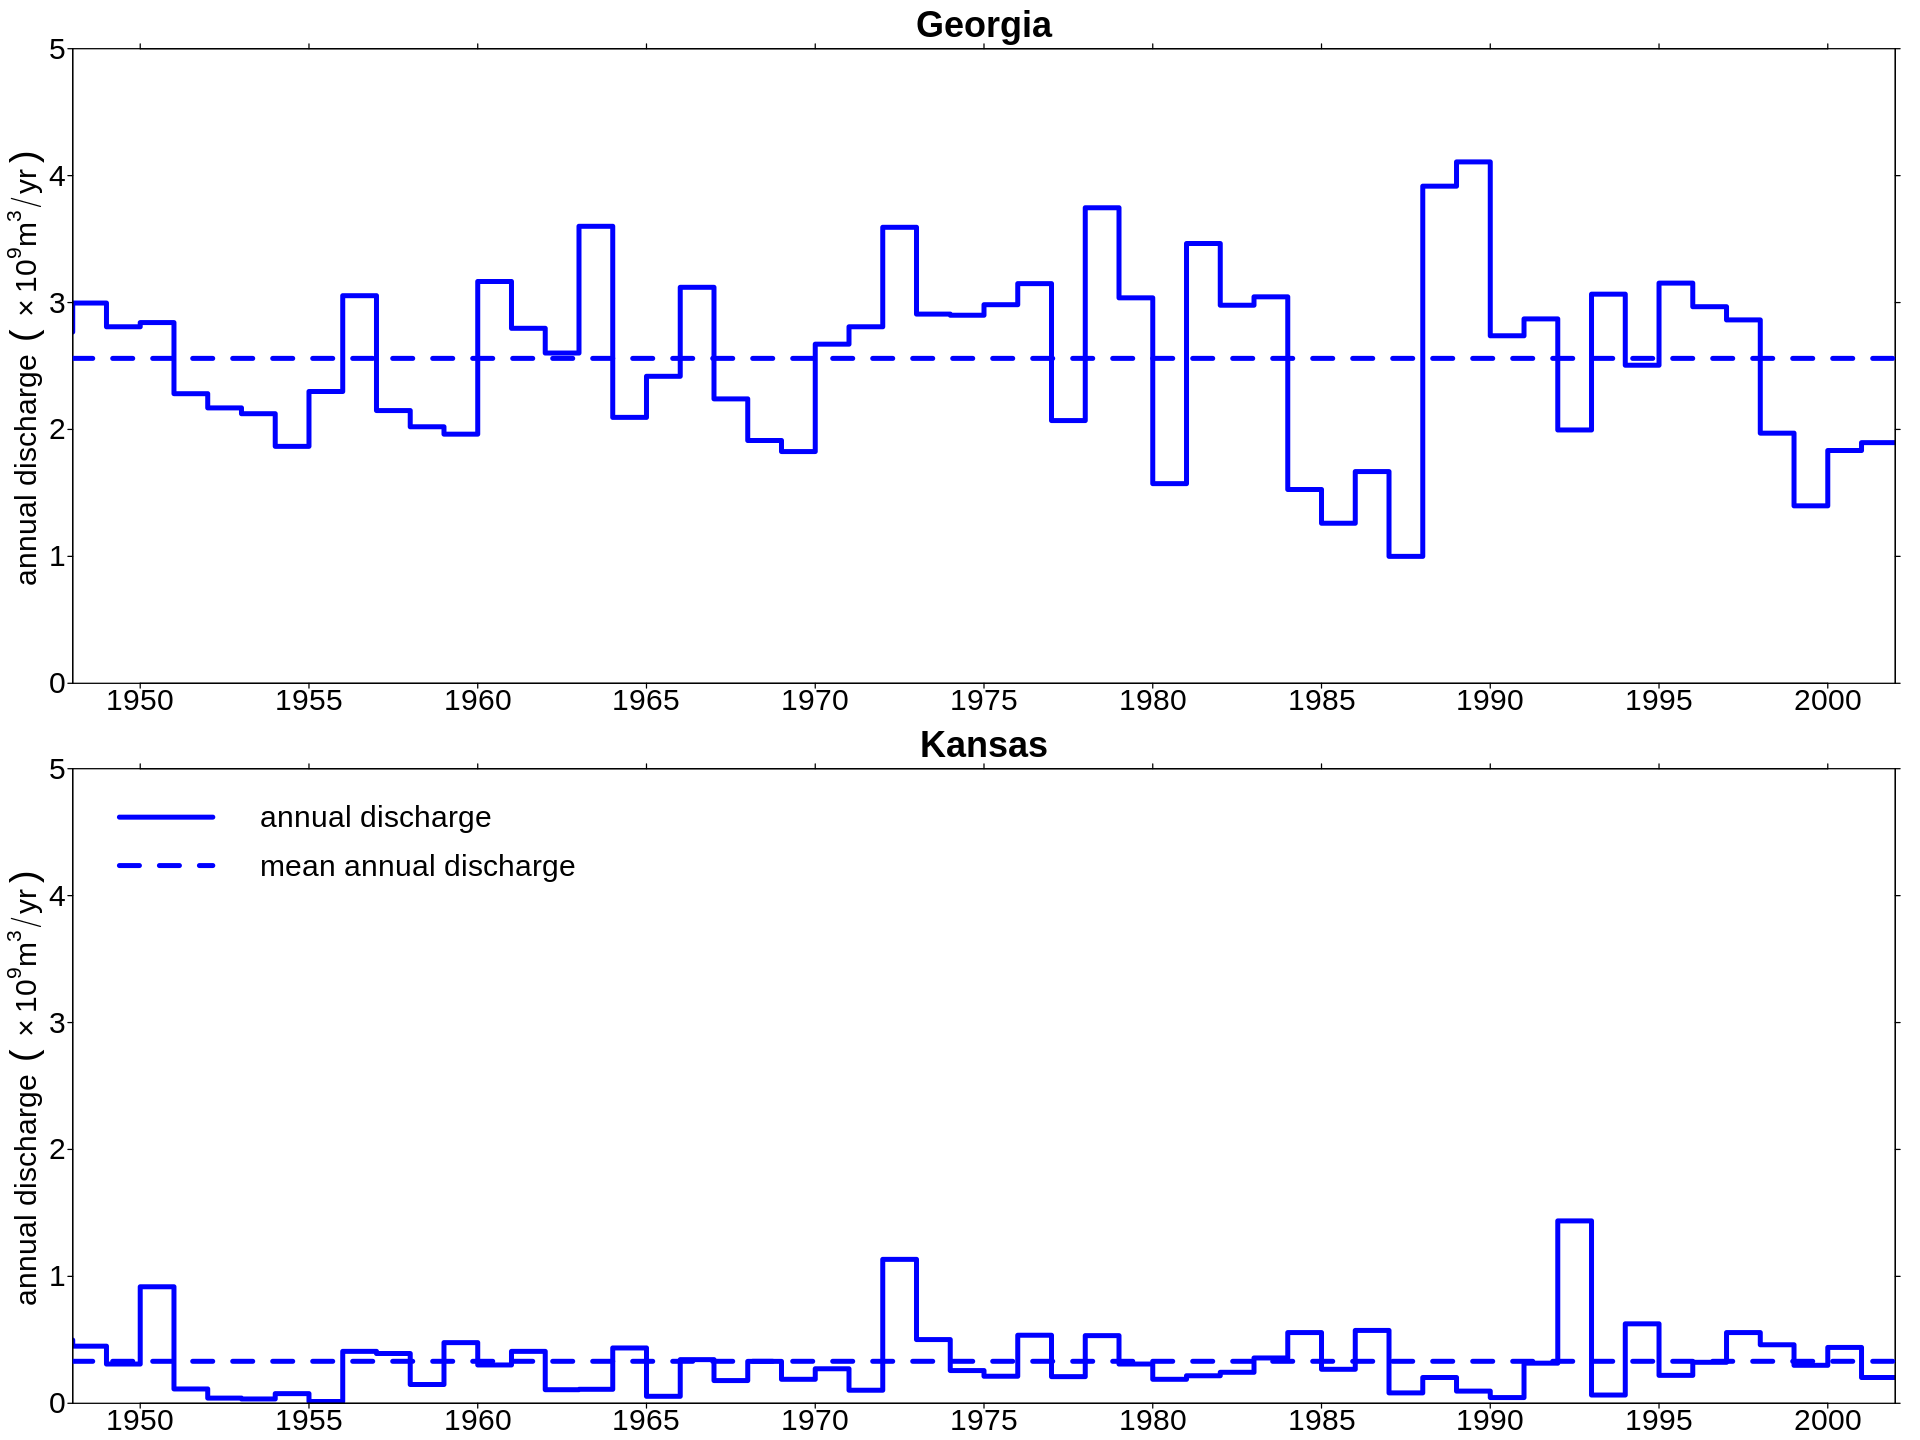

In [11]:
Q_GA_mm <- round(365.25*tapply(GAdata$Q, GAdata$year, mean, na.rm=TRUE))
Q_GA_Gm3yr <- round(Q_GA_mm/1000 * 1602*2.59*1000^2 / 1e9, 3)

Q_KS_mm <- round(365.25*tapply(KSdata$Q, KSdata$year, mean, na.rm=TRUE))
Q_KS_Gm3yr <- round(Q_KS_mm/1000 * 1327*2.59*1000^2 / 1e9, 3)

options(repr.plot.width = 16, repr.plot.height = 12)
layout(matrix(1:2, ncol=1))
par(ps=18, mar=c(1.5,3.0,2,1)+0.03, mgp=c(1.0,0.3,0), tcl=-.2, xaxs='r', yaxs='i', las=1)
 plot(as.numeric(names(Q_GA_Gm3yr)), Q_GA_Gm3yr, type='S',
      xlab='', ylab=expression(paste('annual discharge ', ('' %*% 10^9 * m^3/yr))),
      xlim=c(1950,2000), ylim=c(0,5), lwd=4, col='#0000FF', xaxt='n', main='Georgia')
  axis(1, at=seq(1950, 2000, by=5))
  axis(3, at=seq(1950, 2000, by=5), tick=TRUE, label=FALSE)
  axis(4, tick=TRUE, label=FALSE)
 abline(h=mean(Q_GA_Gm3yr, na.rm=TRUE), lty=2, lwd=4, col='#0000FF')

 plot(as.numeric(names(Q_KS_Gm3yr)), Q_KS_Gm3yr, type='S',
      xlab='', ylab=expression(paste('annual discharge ', ('' %*% 10^9 * m^3/yr))),
      xlim=c(1950,2000), ylim=c(0,5), lwd=4, col='#0000FF', xaxt='n', main='Kansas')
  axis(1, at=seq(1950, 2000, by=5))
  axis(3, at=seq(1950, 2000, by=5), tick=TRUE, label=FALSE)
  axis(4, tick=TRUE, label=FALSE)
 abline(h=mean(Q_KS_Gm3yr, na.rm=TRUE), lty=2, lwd=4, col='#0000FF')
 legend('topleft', legend=c('annual discharge','mean annual discharge'),
        lty=c(1,2), lwd=4, col='#0000FF', bty='n')

This figure compares annual discharge for two MOPEX catchments: Georgia station `02387500` and Kansas station `07144200`.

The daily streamflow values are first averaged by year using `tapply()`. Multiplying by `365.25` converts the mean daily discharge into an annual total expressed as a water depth in `mm/yr`.

The annual depth is then converted into an annual volume in `10^9 m³/yr` using the catchment area. For Georgia the area is `1602 mi²`, and for Kansas the area is `1327 mi²`.

The resulting figure has two panels. Each panel shows the annual discharge time series as a blue step plot, together with a dashed horizontal line showing the long-term mean annual discharge. This allows us to compare both year-to-year variability and the average discharge between the two basins.

## Figure 1.5: Annual precipitation and discharge in Georgia and Kansas

This code reproduces Figure 1.5 from the book by comparing annual precipitation `P` and annual discharge `Q` for the Georgia and Kansas MOPEX catchments.

The discharge series `Q_GA_mm` and `Q_KS_mm` were calculated earlier for Figure 1.3. Here we calculate annual precipitation in the same way.

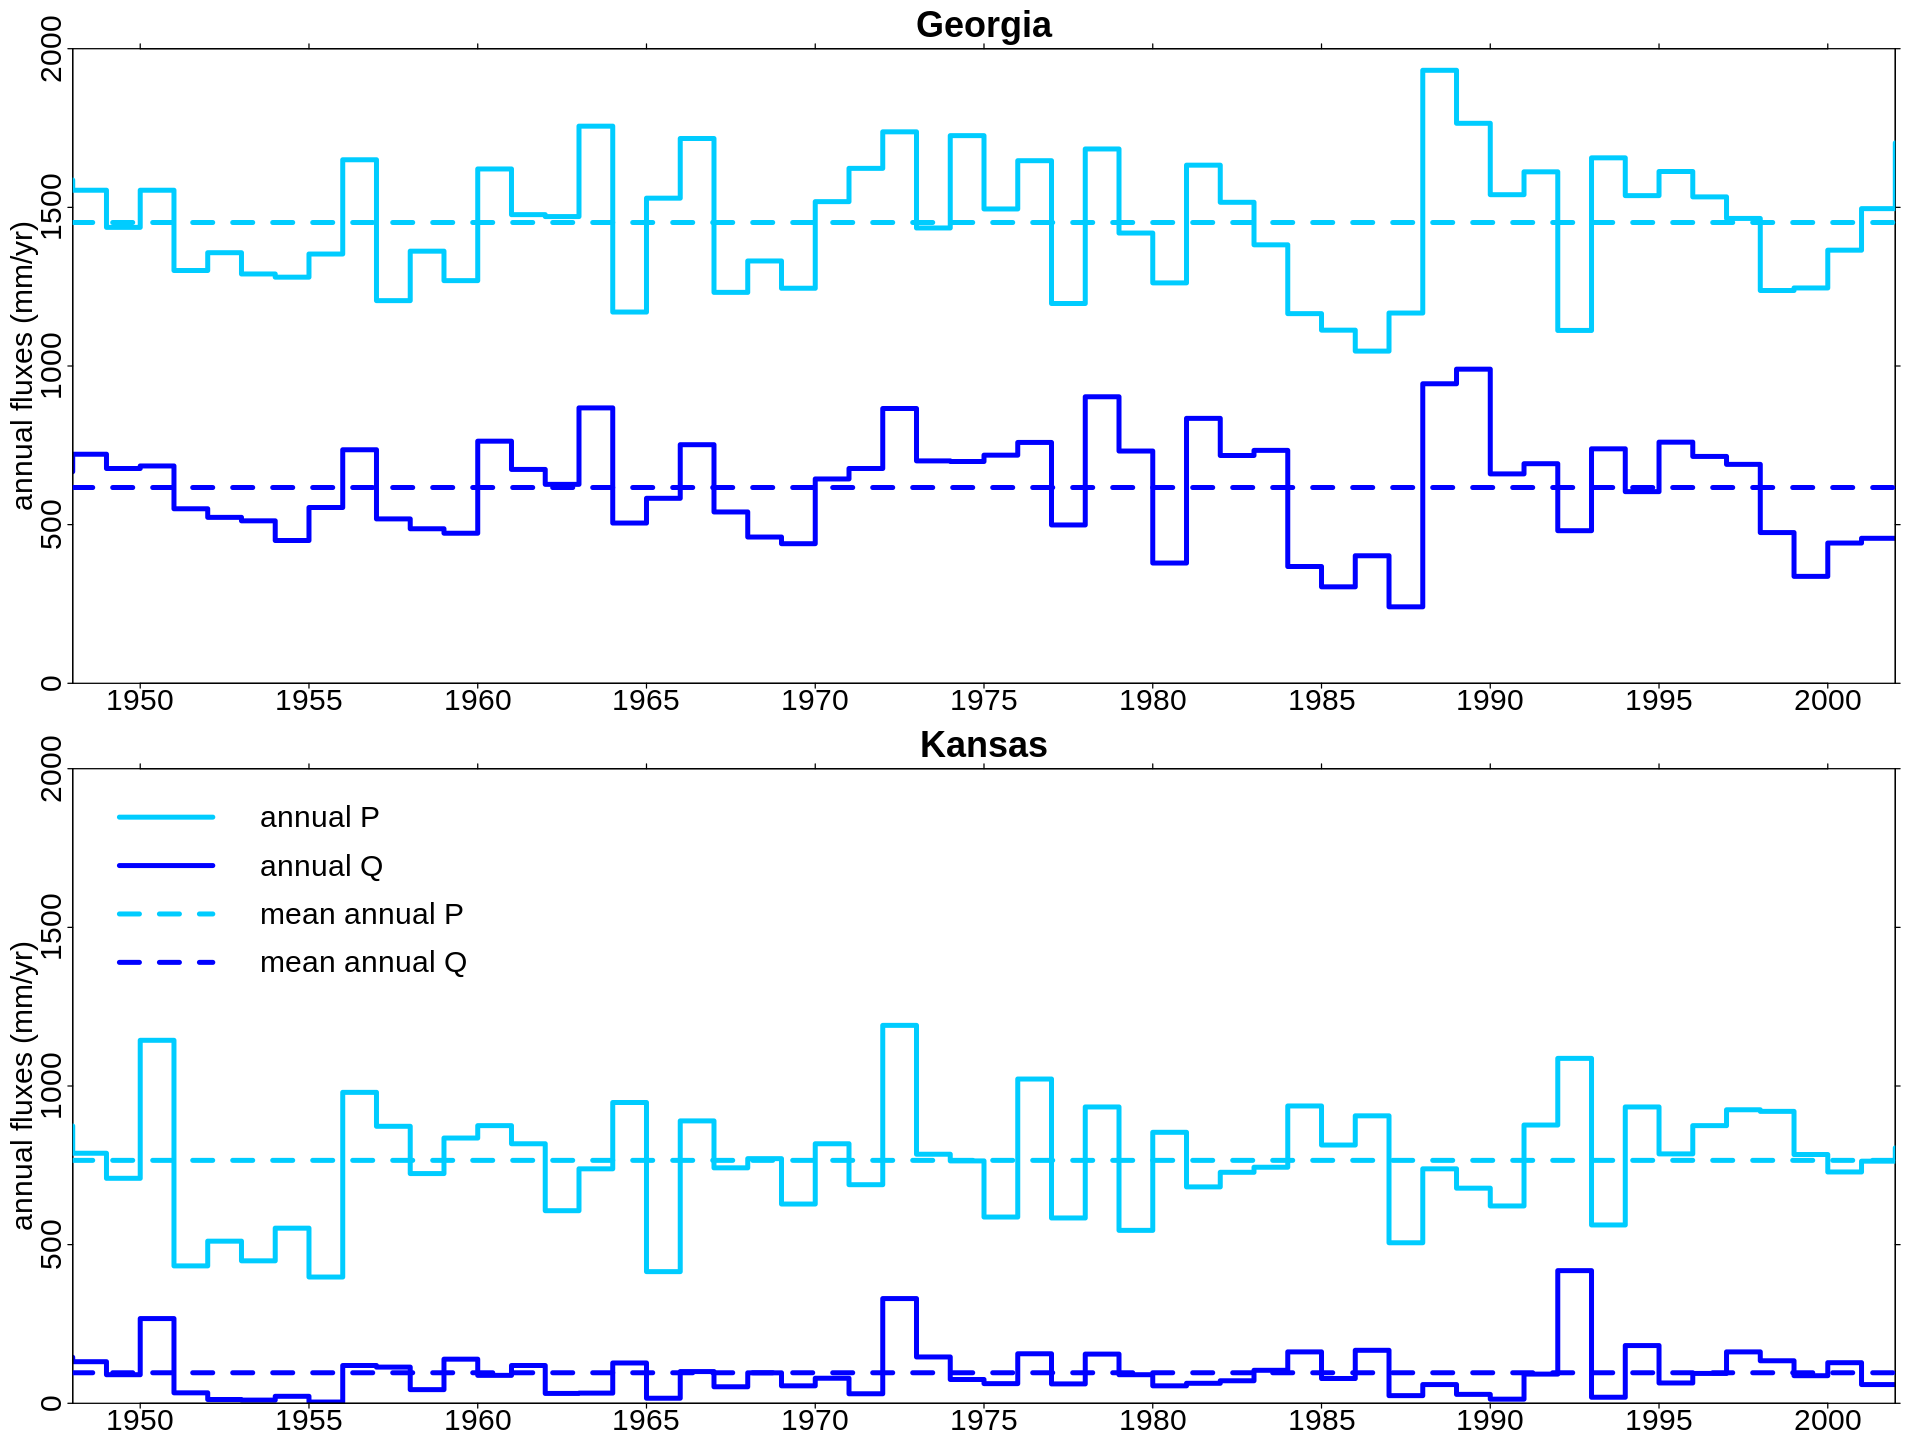

In [12]:
P_GA_mm <- round(365.25*tapply(GAdata$P, GAdata$year, mean, na.rm=TRUE))
P_KS_mm <- round(365.25*tapply(KSdata$P, KSdata$year, mean, na.rm=TRUE))

layout(matrix(1:2, ncol=1))
par(ps=18, mar=c(1.5,3.0,2,1)+0.03, mgp=c(1.5,0.3,0), tcl=-.2, xaxs='r', yaxs='i', las=0)
 plot(as.numeric(names(Q_GA_mm)), Q_GA_mm, type='S', xlab='', ylab='annual fluxes (mm/yr)',
      xlim=c(1950,2000), ylim=c(0,2000), lwd=4, col='#0000FF', xaxt='n', main='Georgia')
  axis(1, at=seq(1950, 2000, by=5))
  axis(3, at=seq(1950, 2000, by=5), tick=TRUE, label=FALSE)
  axis(4, tick=TRUE, label=FALSE)
 lines(as.numeric(names(P_GA_mm)), P_GA_mm, type='S', lwd=4, col='#00CCFF')
 abline(h=mean(Q_GA_mm, na.rm=TRUE), lty=2, lwd=4, col='#0000FF')
 abline(h=mean(P_GA_mm, na.rm=TRUE), lty=2, lwd=4, col='#00CCFF')

 plot(as.numeric(names(Q_KS_mm)), Q_KS_mm, type='S', xlab='', ylab='annual fluxes (mm/yr)',
      xlim=c(1950,2000), ylim=c(0,2000), lwd=4, col='#0000FF', xaxt='n', main='Kansas')
  axis(1, at=seq(1950, 2000, by=5))
  axis(3, at=seq(1950, 2000, by=5), tick=TRUE, label=FALSE)
  axis(4, tick=TRUE, label=FALSE)
 lines(as.numeric(names(P_KS_mm)), P_KS_mm, type='S', lwd=4, col='#00CCFF')
 abline(h=mean(Q_KS_mm, na.rm=TRUE), lty=2, lwd=4, col='#0000FF')
 abline(h=mean(P_KS_mm, na.rm=TRUE), lty=2, lwd=4, col='#00CCFF')
 legend('topleft', legend=c('annual P','annual Q','mean annual P','mean annual Q'),
        lty=c(1,1,2,2), lwd=4, col=rep(c('#00CCFF','#0000FF'), 2), bty='n')

This figure compares annual precipitation `P` and annual discharge `Q` for the Georgia and Kansas catchments.

Daily precipitation values are averaged by year and multiplied by `365.25` to estimate annual precipitation in `mm/yr`. These values are plotted together with the annual discharge values calculated previously.

The solid lines show annual values, and the dashed lines show long-term means. Light blue represents precipitation, while dark blue represents discharge.

By plotting `P` and `Q` on the same scale, we can compare water inputs and outputs for each catchment and see how the two basins differ in climate and runoff response.

## Calculate long-term water-balance statistics for all downloaded stations

So far, we have worked mainly with two example catchments: Georgia and Kansas.  
The next step is to repeat a similar calculation for **all MOPEX `.dly` files** that were downloaded into the `data` folder.

The first line finds every file in the `data` directory whose filename ends in `.dly`.

In [13]:
dly_files <- list.files(path = "data", pattern = "\\.dly$", full.names = TRUE)

mopex_data <- lapply(dly_files, read_mopex_dly)
 names(mopex_data) <- substr(dly_files, 6, 13)

wb <- t(sapply(mopex_data, FUN=function(x) {
                            if (!is.null(dim(x))) {
                             round(365.25*apply(x, 2, mean, na.rm=TRUE))
                            } else {c(NA, NA, NA)}
                           }))[,4:6]
 print(wb)

            P   EP    Q
01064500 1395  708  867
01334500 1194  663  661
01606500  967  716  394
02296750 1296 1214  251
02387500 1452  866  618
03167000  972  773  372
05482500  775  998  173
07144200  766 1350   96
08095000  789 1511   73
09497500  498 1147   81
12098500 1877  659 1264
14359000 1053  850  510


This code reads all `.dly` files in the `data` folder and applies `read_mopex_dly()` to each one.  
The result is a list called `mopex_data`, with one element per station.

For each station, the code calculates long-term mean annual values by averaging the daily data and multiplying by `365.25`.  
The columns retained in `wb` are the main water-balance variables:

- `P`: precipitation
- `EP`: potential evaporation
- `Q`: discharge

The printed table gives a compact comparison of the average annual water balance for all downloaded MOPEX catchments.

## Figure 1.8: Mean annual precipitation and runoff

This code reproduces Figure 1.8 from the book by comparing mean annual precipitation and mean annual runoff for the selected MOPEX catchments.

The object `wb` contains long-term mean annual water-balance values for each station.

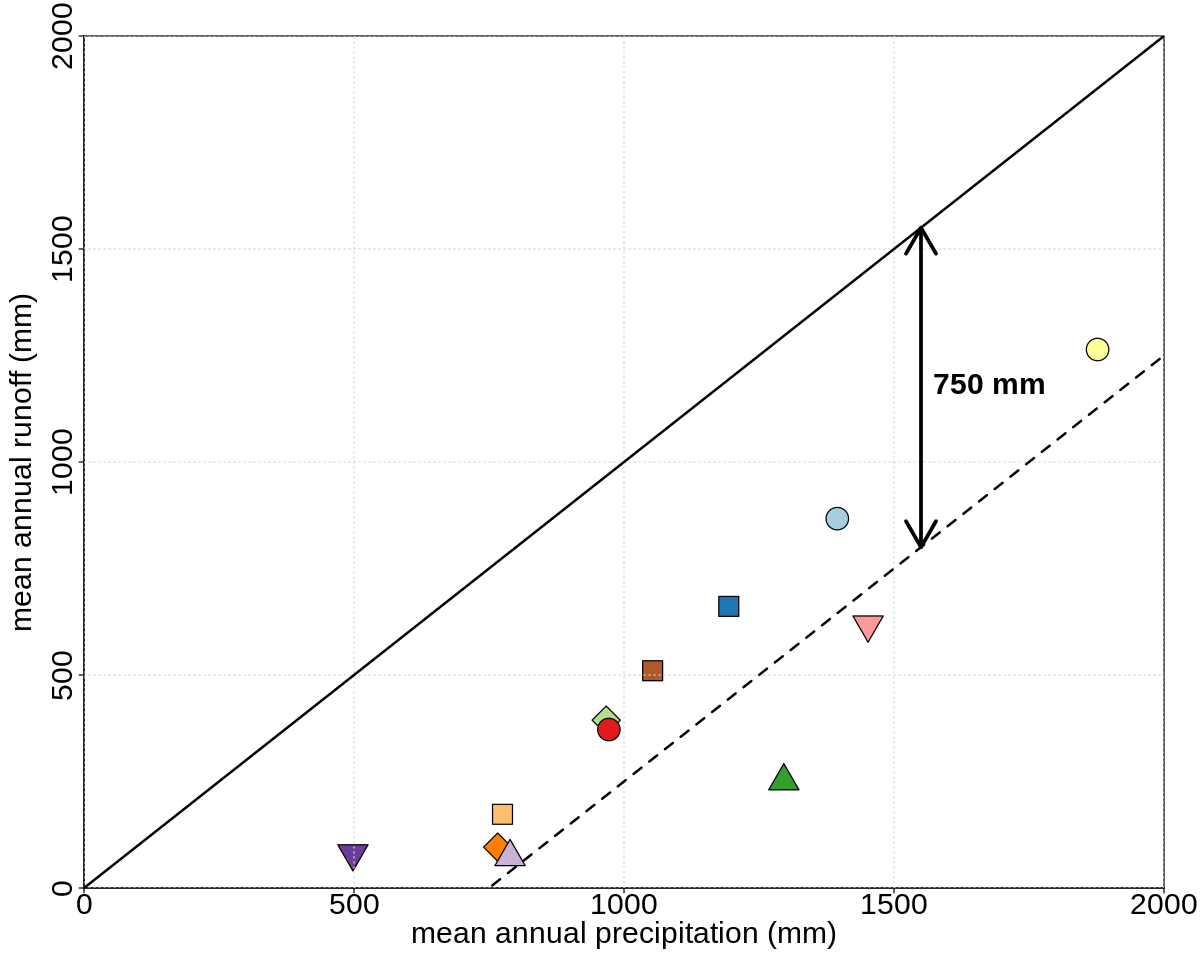

In [14]:
P <- wb[,'P']
EP <- wb[,'EP']
Q <- wb[,'Q']
EP_ov_P <- EP/P
E_ov_P <- (P - Q)/P
Q_ov_P <- Q/P

sitesFigsSiva <- which(rownames(wb) %in% c('02387500','07144200',
          '09497500','01606500','14359000','05482500','01064500',
          '08095000','01334500','03167000','02296750','12098500'))
pchFigsSiva <- c(21:25,21:25,21:22)
colFigsSiva <- c('#a6cee3','#1f78b4','#b2df8a','#33a02c','#fb9a99','#e31a1c',
                 '#fdbf6f','#ff7f00','#cab2d6','#6a3d9a','#ffff99','#b15928')

options(repr.plot.width = 10, repr.plot.height = 8)
par(ps=18, mar=c(2.5,3.0,1,1)+0.50, mgp=c(1.5,0.3,0), tcl=-.2, xaxs='i', yaxs='i', las=0)
 plot(P[sitesFigsSiva], Q[sitesFigsSiva], pch=pchFigsSiva, cex=2.5, bg=colFigsSiva,
      xlim=c(0,2000), ylim=c(0,2000), xlab='mean annual precipitation (mm)', ylab='')
   grid()
  title(ylab='mean annual runoff (mm)', line=2)
  abline(0, 1, lwd=2)
  abline(-750, 1, lty=2, lwd=2)
  arrows(x0=1550, y0=1550-750, y1=1550, length=0.25, angle=30, code=3, lwd=3)
  text(1550, 1550-375, label='750 mm', pos=4, font=2)

This figure compares mean annual precipitation P and mean annual runoff Q for the selected MOPEX catchments.

The values are taken from the water-balance table wb. Each point represents one station, with precipitation on the x-axis and runoff on the y-axis. The symbols and colors match the stations used in the earlier map.

The solid diagonal line shows Q = P. Points below this line indicate that only part of the incoming precipitation leaves the basin as streamflow. The remaining water is mainly lost through evapotranspiration.

The dashed line shows Q = P - 750, and the arrow marks a difference of 750 mm between precipitation and runoff. This helps visualize the approximate evaporative loss for basins that lie near that line.

The code also computes useful ratios such as Q/P, (P - Q)/P, and EP/P, which describe runoff efficiency, evaporative partitioning, and climatic dryness.

## Figure 1.12: Budyko-style water-balance relationships

This code reproduces Figure 1.12 from the book. The figure compares the selected MOPEX catchments using dimensionless water-balance ratios.

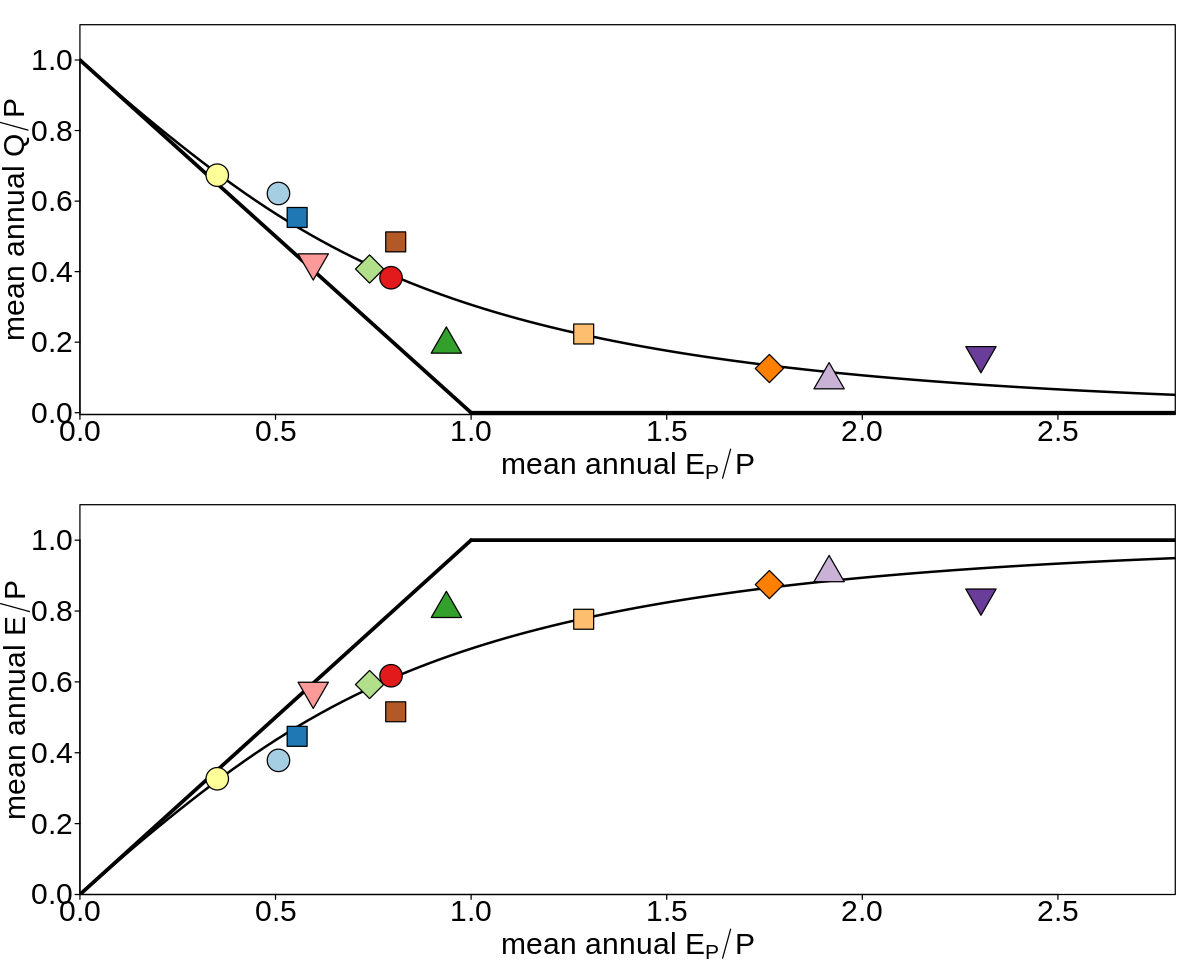

In [15]:
layout(matrix(1:2, ncol=1))
par(ps=18, mar=c(2.7,3.3,1,1)+0.03, mgp=c(1.9,0.3,0), tcl=-.2, xaxs='i', yaxs='i', las=1)
 plot(c(0,2.8), c(-0.005,1.1), type='n',
      xlab=expression(paste('mean annual ', E[P]/P)), ylab=expression(paste('mean annual ', Q/P)))
  segments(x0=c(0,1), y0=c(1,0), x1=c(1,2.8), y1=c(0,0), lwd=3)
  curve(1 - sqrt(x*(1 - exp(-x))*tanh(1/x)), add=TRUE, lwd=2)
 points(EP_ov_P[sitesFigsSiva], Q_ov_P[sitesFigsSiva], pch=pchFigsSiva, cex=2.5, bg=colFigsSiva)

 plot(c(0,2.8), c(0,1.1), type='n',
      xlab=expression(paste('mean annual ', E[P]/P)), ylab=expression(paste('mean annual ', E/P)))
  segments(x0=c(0,1), y0=c(0,1), x1=c(1,2.8), y1=c(1,1), lwd=3)
  curve(sqrt(x*(1 - exp(-x))*tanh(1/x)), add=TRUE, lwd=2)
 points(EP_ov_P[sitesFigsSiva], E_ov_P[sitesFigsSiva], pch=pchFigsSiva, cex=2.5, bg=colFigsSiva)


This figure shows how the selected MOPEX catchments fit within a Budyko-style water-balance framework.

The x-axis is `EP/P`, the ratio of mean annual potential evaporation to mean annual precipitation. This is a measure of climatic dryness.

The upper panel shows `Q/P`, the fraction of precipitation that becomes runoff. The lower panel shows `E/P`, estimated as `(P - Q)/P`, the fraction of precipitation lost to evapotranspiration.

The straight lines show simple limiting cases, while the curved line gives a Budyko-type relationship. The same station symbols and colors used in earlier figures identify the selected catchments.

Together, the two panels show that humid basins generally have higher runoff ratios, while drier basins tend to lose a larger fraction of precipitation to evapotranspiration.

## Figure 1.21: Year-to-year precipitation and runoff for Georgia and Kansas

This code reproduces Figure 1.21 from the book. The figure compares annual precipitation and annual runoff for two individual catchments:

- Georgia station `02387500`
- Kansas station `07144200`

Unlike Figure 1.8, where each point represented the long-term average of a different catchment, this figure shows **year-to-year variability within each catchment**. Each point represents one year. The x-axis shows annual precipitation, and the y-axis shows annual runoff, both in `mm/yr`.

The figure has two side-by-side panels:

- the left panel shows Georgia;
- the right panel shows Kansas.

In each panel, the points show how annual runoff changes from year to year as annual precipitation changes. Years with higher precipitation generally tend to have higher runoff, but the relationship is not one-to-one because part of the precipitation is lost to evapotranspiration, soil moisture storage, groundwater recharge, or other hydrologic processes.


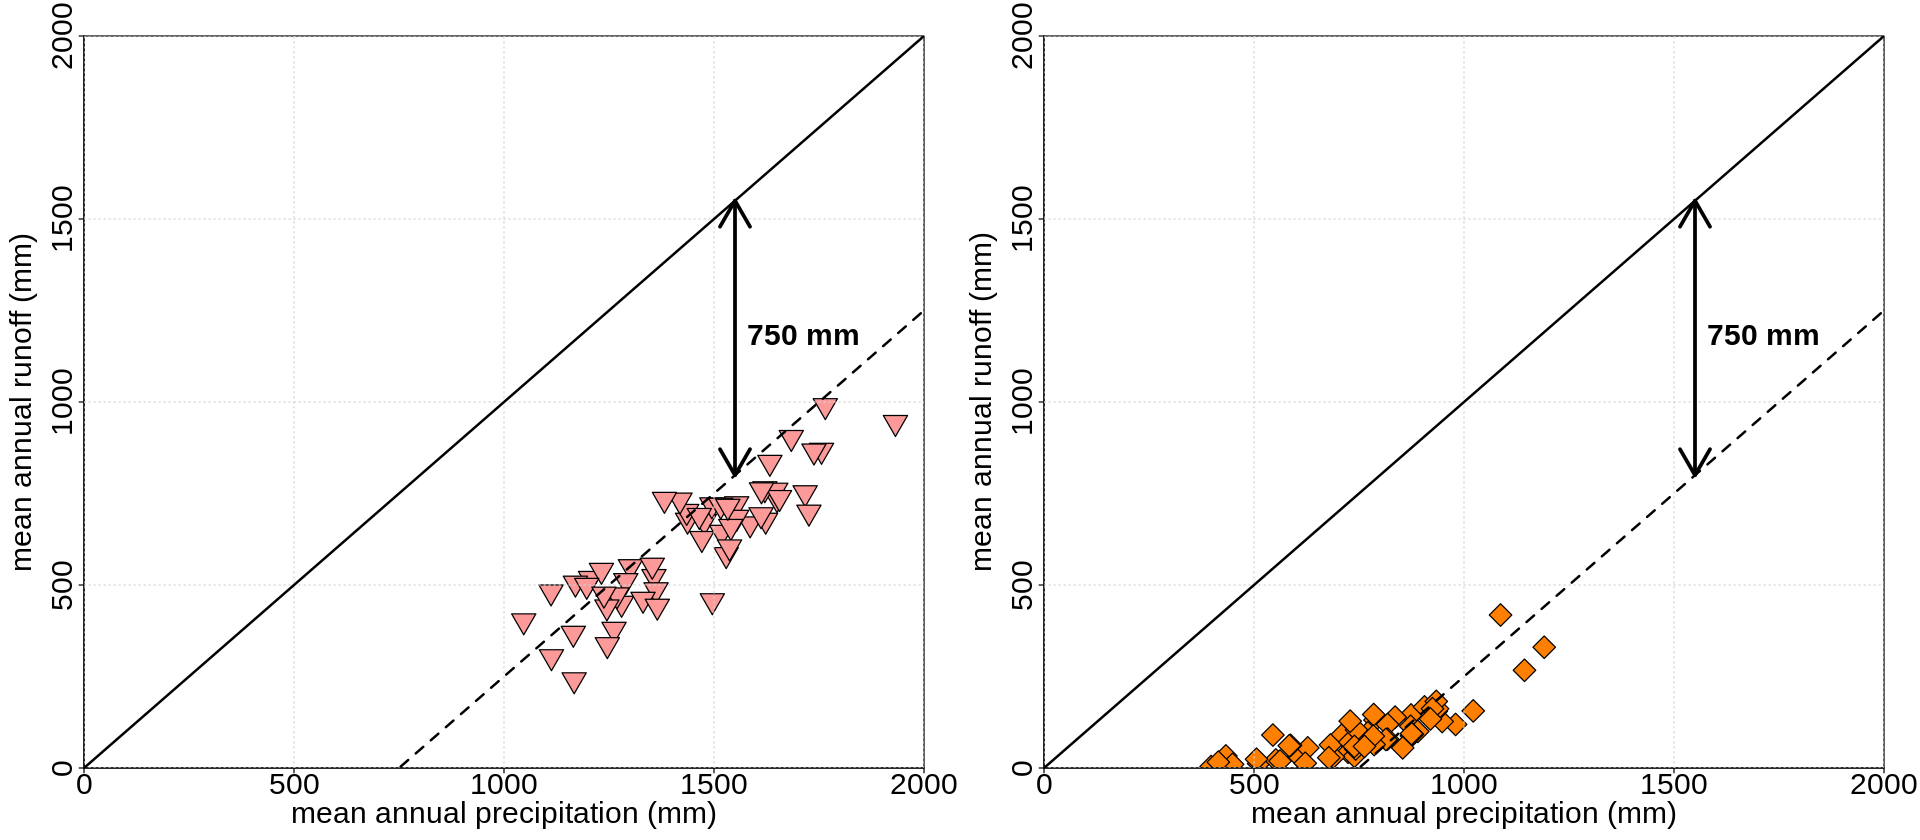

In [19]:
options(repr.plot.width = 16, repr.plot.height = 7)
layout(matrix(1:2, ncol=2))
par(ps=18, mar=c(2.5,3.0,1,1)+0.50, mgp=c(1.5,0.3,0), tcl=-.2, xaxs='i', yaxs='i', las=0)
 plot(P_GA_mm, Q_GA_mm, pch=pchFigsSiva[names(mopex_data) == '02387500'], cex=2, bg=colFigsSiva[names(mopex_data) == '02387500'],
      xlim=c(0,2000), ylim=c(0,2000), xlab='mean annual precipitation (mm)', ylab='')
   grid()
  title(ylab='mean annual runoff (mm)', line=2)
  abline(0, 1, lwd=2)
  abline(-750, 1, lty=2, lwd=2)
  arrows(x0=1550, y0=1550-750, y1=1550, length=0.25, angle=30, code=3, lwd=3)
  text(1550, 1550-375, label='750 mm', pos=4, font=2)

 plot(P_KS_mm, Q_KS_mm, pch=pchFigsSiva[names(mopex_data) == '07144200'], cex=2, bg=colFigsSiva[names(mopex_data) == '07144200'],
      xlim=c(0,2000), ylim=c(0,2000), xlab='mean annual precipitation (mm)', ylab='')
   grid()
  title(ylab='mean annual runoff (mm)', line=2)
  abline(0, 1, lwd=2)
  abline(-750, 1, lty=2, lwd=2)
  arrows(x0=1550, y0=1550-750, y1=1550, length=0.25, angle=30, code=3, lwd=3)
  text(1550, 1550-375, label='750 mm', pos=4, font=2)


This figure compares annual precipitation `P` and annual runoff `Q` for the Georgia and Kansas catchments.

Each point represents one year. The left panel shows Georgia, and the right panel shows Kansas. The x-axis gives annual precipitation in `mm/yr`, while the y-axis gives annual runoff in `mm/yr`.

The solid diagonal line shows `Q = P`, the case where all precipitation becomes runoff. The dashed line shows `Q = P - 750`, and the arrow marks a 750 mm difference between precipitation and runoff.

The figure highlights how runoff varies from year to year with precipitation, and how this relationship differs between the humid Georgia catchment and the drier Kansas catchment.

## Figure 1.23: Annual Budyko-style plot for all selected catchments

This code extends the Budyko-style analysis by plotting **annual values** for each selected MOPEX catchment.

In Figure 1.12, each point represented the long-term mean condition of one catchment. Here, each catchment contributes many points: one point for each year of data. This allows us to see both the differences among catchments and the year-to-year variability within each catchment.

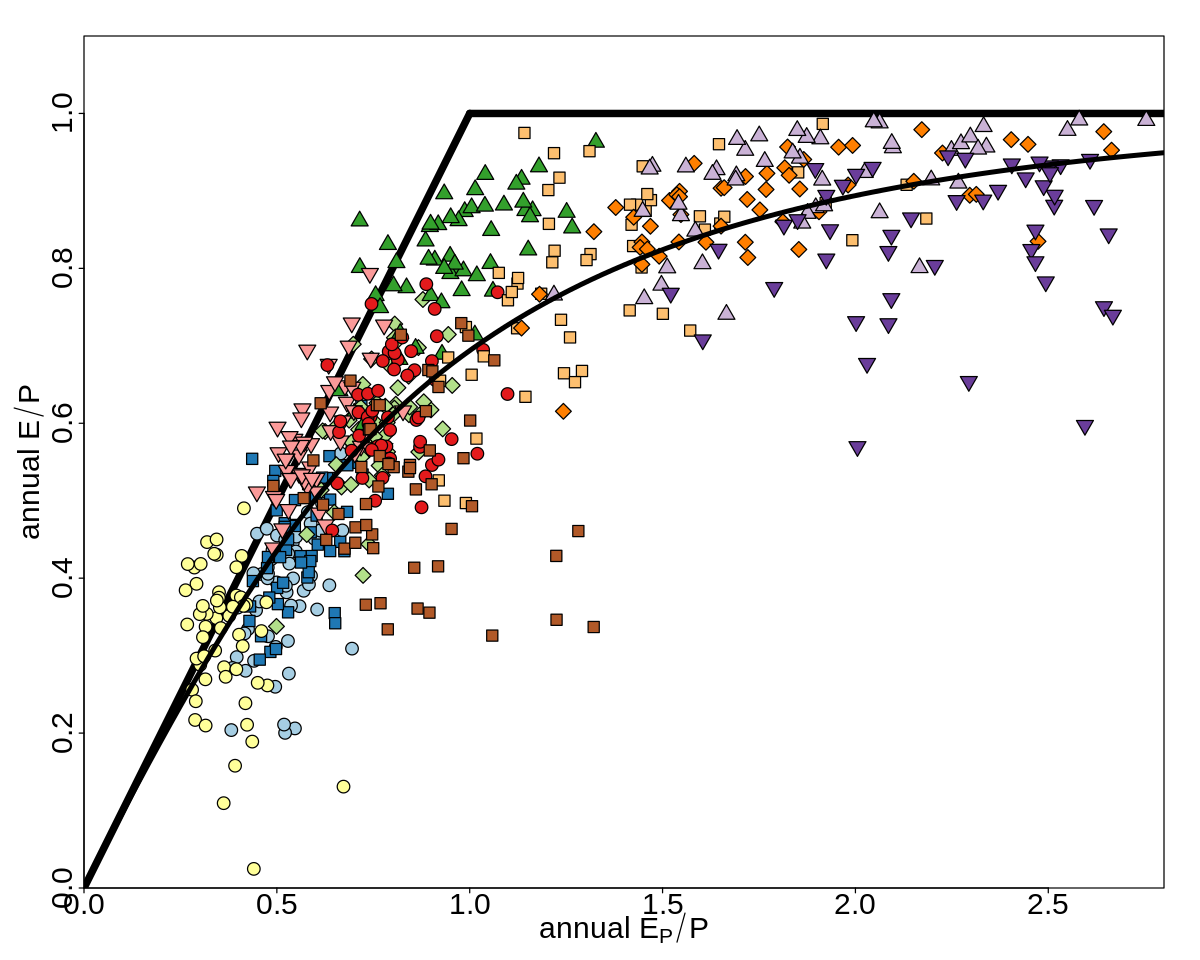

In [21]:
options(repr.plot.width = 10, repr.plot.height = 8)
par(ps=18, mar=c(2.5,3.0,1,1)+0.50, mgp=c(1.5,0.3,0), tcl=-.2, xaxs='i', yaxs='i', las=0)
plot(c(0,2.8), c(0,1.1), type='n', xlab=expression(paste('annual ', E[P]/P)), ylab=expression(paste('annual ', E/P)))
  segments(x0=c(0,1), y0=c(0,1), x1=c(1,2.8), y1=c(1,1), lwd=6)
 for (i in 1:length(sitesFigsSiva)) {
  sss <- mopex_data[[sitesFigsSiva[i]]]
  PP <- round(365.25*tapply(sss$P, sss$year, mean, na.rm=TRUE))
  EE <- round(365.25*tapply(sss$EP, sss$year, mean, na.rm=TRUE))
  QQ <- round(365.25*tapply(sss$Q, sss$year, mean, na.rm=TRUE))
  points(EE/PP, (PP - QQ)/PP, pch=pchFigsSiva[i], cex=1.4, bg=colFigsSiva[i])
 }
 curve(sqrt(x*(1 - exp(-x))*tanh(1/x)), add=TRUE, lwd=4)

This figure shows annual Budyko-style ratios for the selected MOPEX catchments. Unlike the earlier long-term Budyko plot, each point here represents one catchment-year rather than one catchment average.

For each selected station, the code calculates annual precipitation `P`, potential evaporation `EP`, and runoff `Q`. It then plots `EP/P` on the x-axis and `(P - Q)/P` on the y-axis.

The x-axis represents annual climatic dryness, while the y-axis estimates the annual evaporative fraction. The same symbols and colors used in previous figures identify the different catchments.

The straight lines show limiting water-balance behavior, and the curved line shows a Budyko-type relationship. This plot helps show how individual years vary around the long-term climate-water-balance relationship.